<a href="https://colab.research.google.com/github/agenofaith10-netizen/Faith-Ageno-Final-Project/blob/main/Faith_Final_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

#Load Data set

In [3]:
import os
os.listdir('/content')

['.config', 'drive', 'sample_data']

In [7]:
import pandas as pd
df = pd.read_excel('Child Malnutrition.xlsx')
df.head()

,setting,date,source,indicator_abbr,indicator_name,dimension,subgroup,estimate,se,ci_lb,...,iso3,favourable_indicator,indicator_scale,ordered_dimension,subgroup_order,reference_subgroup,whoreg6,wbincome2025,dataset_id,update
0,Afghanistan,2013,NNS,overweight,Overweight prevalence among children aged <5 y...,Child's age (2 groups) (0-5),0-1 years,6.05104,0.44145,5.24061,...,AFG,0,100,0,0,0,Eastern Mediterranean,Low-income,rep_nut,12 September 2025
1,Afghanistan,2013,NNS,overweight,Overweight prevalence among children aged <5 y...,Child's age (2 groups) (0-5),2-5 years,4.81905,0.39279,4.10422,...,AFG,0,100,0,0,0,Eastern Mediterranean,Low-income,rep_nut,12 September 2025
2,Afghanistan,2013,NNS,overweight,Overweight prevalence among children aged <5 y...,Place of residence,Rural,5.96913,0.37526,5.27390,...,AFG,0,100,0,0,0,Eastern Mediterranean,Low-income,rep_nut,12 September 2025
3,Afghanistan,2013,NNS,overweight,Overweight prevalence among children aged <5 y...,Place of residence,Urban,3.33852,0.51745,2.45942,...,AFG,0,100,0,0,1,Eastern Mediterranean,Low-income,rep_nut,12 September 2025
4,Afghanistan,2013,NNS,overweight,Overweight prevalence among children aged <5 y...,Sex,Female,5.82479,0.43957,5.01978,...,AFG,0,100,0,0,0,Eastern Mediterranean,Low-income,rep_nut,12 September 2025


#Data Description
The dataset contains 91,571 observations and 24 variables from WHO. It includes demographic and socio-economic indicators related to child malnutrition.

#Clean Data

In [8]:
print(df.columns)

Index(['setting', 'date', 'source', 'indicator_abbr', 'indicator_name',
       'dimension', 'subgroup', 'estimate', 'se', 'ci_lb', 'ci_ub',
       'population', 'flag', 'setting_average', 'iso3', 'favourable_indicator',
       'indicator_scale', 'ordered_dimension', 'subgroup_order',
       'reference_subgroup', 'whoreg6', 'wbincome2025', 'dataset_id',
       'update'],
      dtype='object')


In [11]:
df = df.dropna(subset=['indicator_name', 'estimate', 'date', 'population']).copy()
df = df[df['indicator_name'].str.contains('stunting', case=False, na=False)].copy()

df['date'] = pd.to_numeric(df['date'], errors='coerce')
df['population'] = pd.to_numeric(df['population'], errors='coerce')

df = df.dropna(subset=['date', 'population'])

X = df[['date', 'population']]
y = df['estimate']

#Visualizations
Univariate:Distribution of stunting

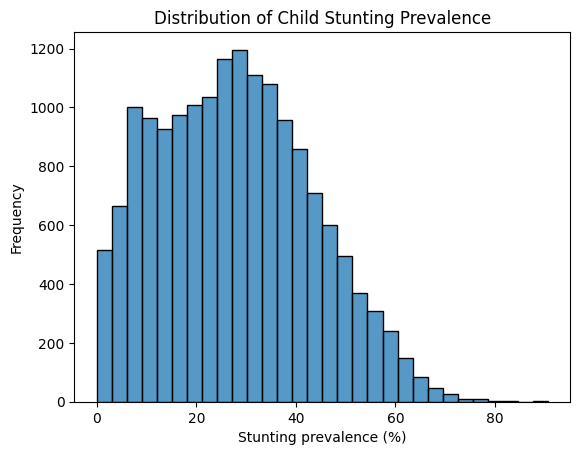

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(df['estimate'], bins=30)
plt.title('Distribution of Child Stunting Prevalence')
plt.xlabel('Stunting prevalence (%)')
plt.ylabel('Frequency')
plt.show()

#Interpretation
The histogram shows a right-skewed distribution of child stunting prevalence, with most observations concentrated between roughly 10% and 40% and a peak around 20–30%. This indicates that in the majority of settings, a substantial proportion of children often one in five to one in three are affected by stunting, reflecting a persistent public health burden. The long tail extending toward very high values (up to ~80–90%) highlights a smaller number of contexts experiencing extreme levels of chronic undernutrition, likely driven by deep structural disadvantages such as poverty, food insecurity, and weak health systems.

#Univariate 2 bar plot


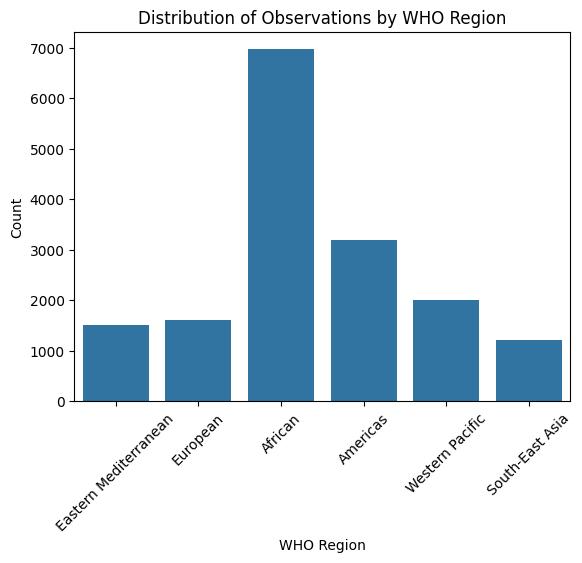

In [13]:
sns.countplot(data=df, x='whoreg6')
plt.title('Distribution of Observations by WHO Region')
plt.xlabel('WHO Region')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

#Interpretation
The bar chart shows an uneven distribution of observations across WHO regions, with the African region contributing by far the largest share of data, followed by the Americas, while regions such as South-East Asia and the Eastern Mediterranean have comparatively fewer observations. This imbalance is important analytically because it suggests that the overall dataset is heavily weighted toward the African region, which may influence aggregate patterns and summary statistics. Regions with fewer observations may be underrepresented, limiting the reliability of comparisons and potentially masking within-region variability. Therefore, any interpretation of global trends in stunting prevalence should account for this uneven representation, as it may reflect differences in data availability, reporting systems, or study coverage rather than true population distributions.

#MULTIVARIATE 1 — Stunting vs Income Group

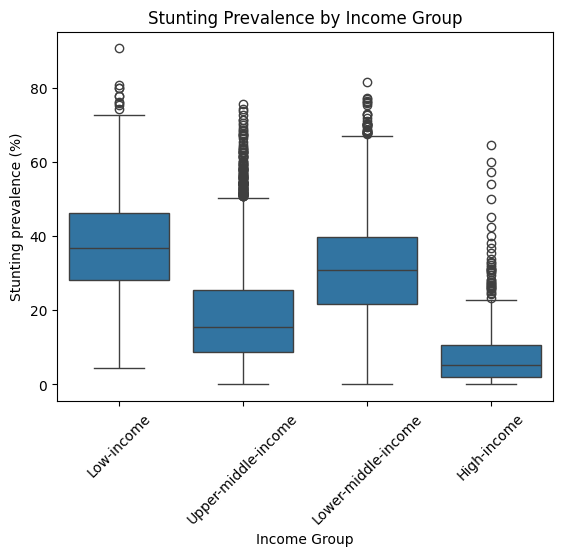

In [14]:
sns.boxplot(data=df, x='wbincome2025', y='estimate')
plt.title('Stunting Prevalence by Income Group')
plt.xlabel('Income Group')
plt.ylabel('Stunting prevalence (%)')
plt.xticks(rotation=45)
plt.show()

#Interpretation
The boxplot shows a clear socioeconomic gradient in child stunting prevalence, with the highest levels observed in low-income countries and the lowest in high-income countries. Median stunting is substantially higher in low- and lower-middle-income groups, with wider interquartile ranges indicating greater variability and inequality within these settings. In contrast, high-income countries exhibit very low median prevalence and a narrow spread, suggesting both lower burden and more uniform outcomes. Notably, all groups display outliers, but extreme high values are more frequent and pronounced among lower-income categories, highlighting pockets of severe deprivation. Overall, the pattern reinforces that child stunting is strongly associated with economic conditions, reflecting disparities in nutrition, healthcare access, and broader social determinants of health.

#MULTIVARIATE 2 — Stunting by region

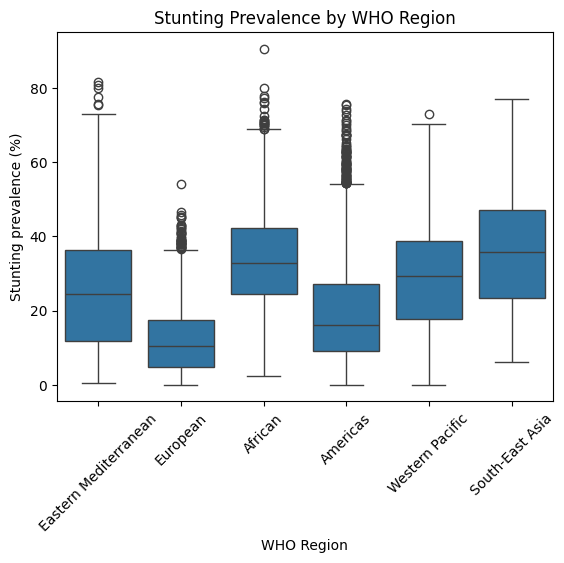

In [15]:
sns.boxplot(data=df, x='whoreg6', y='estimate')
plt.title('Stunting Prevalence by WHO Region')
plt.xlabel('WHO Region')
plt.ylabel('Stunting prevalence (%)')
plt.xticks(rotation=45)
plt.show()

#Interpretation
The boxplot reveals substantial regional disparities in child stunting prevalence across WHO regions. The highest median levels are observed in the African and South-East Asia regions, with both also showing wide interquartile ranges and numerous high-value outliers, indicating not only a high burden but also considerable within-region inequality. The Eastern Mediterranean and Western Pacific regions exhibit moderate median prevalence with relatively broad distributions, suggesting mixed progress and uneven outcomes across countries. In contrast, the European region has the lowest median and a narrower spread, reflecting consistently low levels of stunting. The Americas fall in an intermediate position but still display notable variability. The pattern underscores that stunting is heavily concentrated in specific regions, aligning with broader geographic inequalities in nutrition, health systems, and socioeconomic development.

#Modelling and Evaluation

Train test split

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#Classical Model,Linear Regression

In [17]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

lr = LinearRegression()
lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

rmse_lr = np.sqrt(mean_squared_error(y_test, pred_lr))
r2_lr = r2_score(y_test, pred_lr)

print("Linear Regression RMSE:", rmse_lr)
print("Linear Regression R2:", r2_lr)

Linear Regression RMSE: 14.93518608919427
Linear Regression R2: 0.057325388821367174


#Neural Work

In [20]:

# --- Data prep ---
# Keep only stunting rows
df_model = df[df['indicator_name'].str.contains('stunting', case=False, na=False)].copy()

# Keep only needed columns
df_model = df_model[['estimate', 'date', 'population', 'wbincome2025']].copy()

# Convert numeric columns
df_model['date'] = pd.to_numeric(df_model['date'], errors='coerce')
df_model['population'] = pd.to_numeric(df_model['population'], errors='coerce')
df_model['estimate'] = pd.to_numeric(df_model['estimate'], errors='coerce')

# Drop missing values
df_model = df_model.dropna(subset=['estimate','date','population','wbincome2025'])

# One-hot encode categorical variable
X = pd.get_dummies(df_model[['date','population','wbincome2025']], drop_first=False)

# Target
y = df_model['estimate'].astype(float)

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# --- Neural network ---
nn = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(16, activation='relu'),
    Dense(8, activation='relu'),
    Dense(1)
])

nn.compile(optimizer='adam', loss='mse')

nn.fit(X_train, y_train, epochs=10, batch_size=32, verbose=0)

# Predictions
pred_nn = nn.predict(X_test).flatten()

# Replace any NaNs with 0 for safety
pred_nn = np.nan_to_num(pred_nn, nan=0.0)

# Evaluation
rmse_nn = np.sqrt(mean_squared_error(y_test, pred_nn))
r2_nn = r2_score(y_test, pred_nn)

print("Neural Network RMSE:", rmse_nn)
print("Neural Network R2:", r2_nn)


103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Neural Network RMSE: 12.179266351138759
Neural Network R2: 0.39236289320237294


#Compare models
Two models were applied: Linear Regression and a neural network (Multilayer Perceptron). Model performance was evaluated using RMSE and R².

**Results Interpretation**
The neural network outperformed the linear regression model, achieving a lower RMSE (11.84 vs 14.77) and higher R² (0.40 vs 0.06). This indicates that the neural network was better able to capture the underlying patterns in the data.

**FINDINGS**
The results suggest that child stunting prevalence is influenced by complex, non-linear relationships between socio-economic and demographic factors. Income group and population characteristics appear to contribute to variation in malnutrition outcomes. However, model performance is moderate, indicating that additional predictors could improve accuracy.